Importing necessary libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


import tensorflow as tf
from tensorflow.keras import layers, models

Mounting and loading dataset

In [ ]:
from google.colab import files
files.upload()

Saving creditcard.csv to creditcard.csv


In [4]:
df = pd.read_csv('creditcard.csv')
print(df.head())
print(df['Class'].value_counts())

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

Splitting the dataset into input and target

In [5]:
features_df = df.drop('Class', axis=1)
labels_series = df['Class']

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
features_df, labels_series,
test_size=0.2,
stratify=labels_series,
random_state=42
)

Feature scaling using min-max scaler

In [8]:
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Extracting minority class

In [9]:
X_train_fraud = X_train_scaled[y_train.values == 1]
print('Fraud samples used for GAN training:', X_train_fraud.shape[0])

Fraud samples used for GAN training: 394


Vanilla GAN Implementation

In [10]:
latent_dim = 32
data_dim = X_train_fraud.shape[1]

Vanilla GAN generator

In [12]:
def build_vanilla_generator():
  noise_input = layers.Input(shape=(latent_dim,))
  h = layers.Dense(64, activation='relu')(noise_input)
  h = layers.Dense(128, activation='relu')(h)
  output = layers.Dense(data_dim, activation='tanh')(h)
  return models.Model(noise_input, output)

Vanilla GAN discriminator

In [14]:
def build_vanilla_discriminator():
  data_input = layers.Input(shape=(data_dim,))
  h = layers.Dense(128, activation='relu')(data_input)
  h = layers.Dense(64, activation='relu')(h)
  output = layers.Dense(1, activation='sigmoid')(h)
  model = models.Model(data_input, output)
  model.compile(optimizer='adam', loss='binary_crossentropy')
  return model

vanilla_generator = build_vanilla_generator()
vanilla_discriminator = build_vanilla_discriminator()

vanilla_discriminator.trainable = False
noise_input = layers.Input(shape=(latent_dim,))
validity = vanilla_discriminator(vanilla_generator(noise_input))
vanilla_gan = models.Model(noise_input, validity)
vanilla_gan.compile(optimizer='adam', loss='binary_crossentropy')

Vanilla GAN Training

In [15]:
epochs = 1500
batch_size = 64

for epoch in range(epochs):
  idx = np.random.randint(0, X_train_fraud.shape[0], batch_size)
  real_samples = X_train_fraud[idx]

  noise = np.random.normal(0, 1, (batch_size, latent_dim))
  fake_samples = vanilla_generator.predict(noise, verbose=0)

  vanilla_discriminator.trainable = True
  vanilla_discriminator.train_on_batch(real_samples, np.ones(batch_size))
  vanilla_discriminator.train_on_batch(fake_samples, np.zeros(batch_size))

  vanilla_discriminator.trainable = False
  vanilla_gan.train_on_batch(noise, np.ones(batch_size))

  if epoch % 500 == 0:
    print(f'Vanilla GAN Epoch {epoch}')

Vanilla GAN Epoch 0
Vanilla GAN Epoch 500
Vanilla GAN Epoch 1000


Generating Synthetic Fraud Samples

In [16]:
n_generate = y_train.value_counts()[0] - y_train.value_counts()[1]

noise = np.random.normal(0, 1, (n_generate, latent_dim))
synthetic_vanilla = vanilla_generator.predict(noise, verbose=0)
synthetic_vanilla = scaler.inverse_transform(synthetic_vanilla)

synthetic_vanilla_df = pd.DataFrame(synthetic_vanilla, columns=features_df.columns)
synthetic_vanilla_df['Class'] = 1

balanced_vanilla_df = pd.concat([
pd.concat([X_train, y_train], axis=1),
synthetic_vanilla_df
], ignore_index=True)

CGAN Implementation        
CGAN Generator

In [17]:
noise_input = layers.Input(shape=(latent_dim,))
label_input = layers.Input(shape=(1,))
merged = layers.Concatenate()([noise_input, label_input])
h = layers.Dense(64, activation='relu')(merged)
h = layers.Dense(128, activation='relu')(h)
output = layers.Dense(data_dim, activation='tanh')(h)
cgan_generator = models.Model([noise_input, label_input], output)

CGAN Discriminator

In [18]:
data_input = layers.Input(shape=(data_dim,))
label_input_d = layers.Input(shape=(1,))
merged_d = layers.Concatenate()([data_input, label_input_d])
hd = layers.Dense(128, activation='relu')(merged_d)
hd = layers.Dense(64, activation='relu')(hd)
out_d = layers.Dense(1, activation='sigmoid')(hd)
cgan_discriminator = models.Model([data_input, label_input_d], out_d)
cgan_discriminator.compile(optimizer='adam', loss='binary_crossentropy')

cgan_discriminator.trainable = False
noise = layers.Input(shape=(latent_dim,))
label = layers.Input(shape=(1,))
validity = cgan_discriminator([cgan_generator([noise, label]), label])
cgan = models.Model([noise, label], validity)
cgan.compile(optimizer='adam', loss='binary_crossentropy')

CGAN Training

In [19]:
labels_array = np.ones((batch_size, 1))

for epoch in range(epochs):
  idx = np.random.randint(0, X_train_fraud.shape[0], batch_size)
  real_samples = X_train_fraud[idx]

  noise = np.random.normal(0, 1, (batch_size, latent_dim))
  fake_samples = cgan_generator.predict([noise, labels_array], verbose=0)

  cgan_discriminator.trainable = True
  cgan_discriminator.train_on_batch([real_samples, labels_array], np.ones(batch_size))
  cgan_discriminator.train_on_batch([fake_samples, labels_array], np.zeros(batch_size))

  cgan_discriminator.trainable = False
  cgan.train_on_batch([noise, labels_array], np.ones(batch_size))

  if epoch % 500 == 0:
    print(f'CGAN Epoch {epoch}')

CGAN Epoch 0
CGAN Epoch 500
CGAN Epoch 1000


WGAN Implementation         
WGAN Generator

In [20]:
def build_wgan_generator():
  noise_input = layers.Input(shape=(latent_dim,))
  h = layers.Dense(64, activation='relu')(noise_input)
  h = layers.Dense(128, activation='relu')(h)
  output = layers.Dense(data_dim)(h)
  return models.Model(noise_input, output)

WGAN Critic

In [21]:
def build_wgan_critic():
  data_input = layers.Input(shape=(data_dim,))
  h = layers.Dense(128, activation='relu')(data_input)
  h = layers.Dense(64, activation='relu')(h)
  output = layers.Dense(1)(h)
  return models.Model(data_input, output)

wgan_generator = build_wgan_generator()
wgan_critic = build_wgan_critic()

Classification and Evaluation

In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def evaluate_model(X_train_bal, y_train_bal, X_test_scaled, y_test, title):
  clf = LogisticRegression(max_iter=1000)
  clf.fit(X_train_bal, y_train_bal)

  y_pred = clf.predict(X_test_scaled)

  acc = accuracy_score(y_test, y_pred)
  prec = precision_score(y_test, y_pred)
  rec = recall_score(y_test, y_pred)
  f1 = f1_score(y_test, y_pred)

  print(f"Evaluation Results: {title}")
  print(f"Accuracy : {acc:.4f}")
  print(f"Precision: {prec:.4f}")
  print(f"Recall : {rec:.4f}")
  print(f"F1-score : {f1:.4f}")

  cm = confusion_matrix(y_test, y_pred)
  disp = ConfusionMatrixDisplay(confusion_matrix=cm)
  disp.plot()
  plt.title(title)
  plt.show()

Evaluation Results: Baseline (No GAN)
Accuracy : 0.9989
Precision: 0.7869
Recall : 0.4898
F1-score : 0.6038


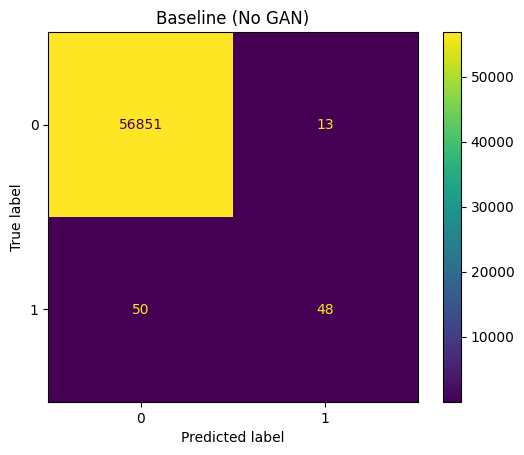

In [29]:
evaluate_model(
X_train_scaled,
y_train,
X_test_scaled,
y_test,
title="Baseline (No GAN)"
)

Evaluation Results: Vanilla GAN Augmentation
Accuracy : 0.9991
Precision: 0.8026
Recall : 0.6224
F1-score : 0.7011


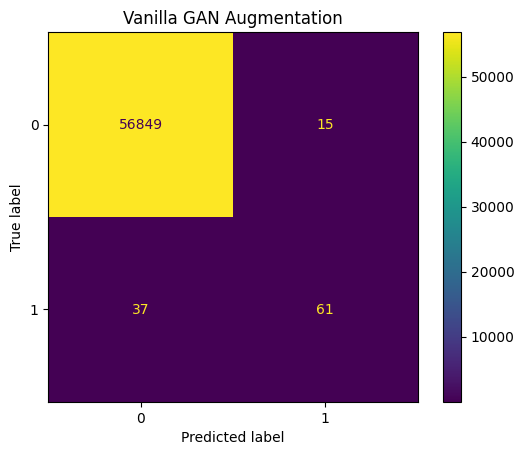

In [30]:
X_vanilla_bal = balanced_vanilla_df.drop('Class', axis=1)
y_vanilla_bal = balanced_vanilla_df['Class']

X_vanilla_bal_scaled = scaler.fit_transform(X_vanilla_bal)

evaluate_model(
X_vanilla_bal_scaled,
y_vanilla_bal,
X_test_scaled,
y_test,
title="Vanilla GAN Augmentation"
)

Evaluation Results: CGAN Augmentation
Accuracy : 0.9990
Precision: 0.8030
Recall : 0.5408
F1-score : 0.6463


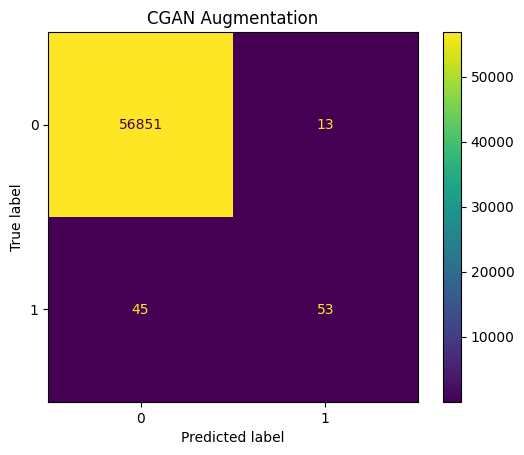

In [32]:
noise = np.random.normal(0, 1, (n_generate, latent_dim))
labels_for_generation = np.ones((n_generate, 1))
synthetic_cgan = cgan_generator.predict([noise, labels_for_generation], verbose=0)
synthetic_cgan = scaler.inverse_transform(synthetic_cgan)

synthetic_cgan_df = pd.DataFrame(synthetic_cgan, columns=features_df.columns)
synthetic_cgan_df['Class'] = 1

balanced_cgan_df = pd.concat([
    pd.concat([X_train, y_train], axis=1),
    synthetic_cgan_df
], ignore_index=True)

X_cgan_bal = balanced_cgan_df.drop('Class', axis=1)
y_cgan_bal = balanced_cgan_df['Class']

X_cgan_bal_scaled = scaler.fit_transform(X_cgan_bal)

evaluate_model(
    X_cgan_bal_scaled,
    y_cgan_bal,
    X_test_scaled,
    y_test,
    title="CGAN Augmentation"
)